# 05: Soliton Collisions and Integrability

**Summary**: We demonstrate the elastic collision of two optical solitons — one of the most
remarkable properties of the nonlinear Schrodinger equation (NLSE). Two solitons, given
opposite frequency offsets (and hence opposite group velocities), collide and pass through
each other, emerging with their shapes and amplitudes restored within numerical tolerance
and with the expected position/phase shifts. The initialized field is a well-separated
approximate two-soliton superposition; this elasticity is a hallmark of **integrability**.

**Key results**:
- Two N=1 solitons collide and pass through each other
- Post-collision peak powers, widths, local energies, velocities, and sech-like shapes
  recover within tolerance
- The collision is consistent with elastic recovery: no significant tail energy, no lasting
  shape change, no amplitude loss within tolerance
- Faster collisions (larger frequency offsets) produce cleaner elasticity

**Physics context**: Soliton collisions were first studied theoretically by Zakharov & Shabat
(1972) using the inverse scattering transform. They are central to understanding soliton-based
wavelength-division multiplexing (WDM) in fiber-optic communications, where pulses at different
wavelengths inevitably collide during propagation.

## Theory: Soliton Collisions and Integrability

### The Inverse Scattering Transform

The NLSE belongs to a special class of PDEs called **integrable systems**. It can be solved
exactly using the inverse scattering transform (IST), which is the nonlinear analog of the
Fourier transform:

| Fourier Transform | Inverse Scattering Transform |
|-------------------|------------------------------|
| Decomposes linear waves into sinusoidal modes | Decomposes nonlinear waves into solitons + radiation |
| Modes evolve independently (no interaction) | Solitons evolve independently (elastic collisions) |
| Superposition principle holds | "Nonlinear superposition" holds |

### Two-Soliton Initial Condition

To create two colliding solitons, we superpose two frequency-shifted sech pulses:

$$u_0(\tau) = \text{sech}(\tau - \tau_1) e^{i\Omega_1 \tau} + \text{sech}(\tau - \tau_2) e^{i\Omega_2 \tau}$$

- $\tau_1, \tau_2$: initial positions (separated in time)
- $\Omega_1, \Omega_2$: frequency offsets (give different group velocities)
- Each soliton drifts at rate $d\tau/d\xi = s \cdot \Omega$ in the co-moving frame

With $\Omega_1 = +\Omega$ and $\Omega_2 = -\Omega$, the solitons approach each other at
relative velocity $2s\Omega$.

### What "Elastic" Means

After the collision:
- Each soliton has the **same amplitude** as before
- Each soliton has the **same width** as before
- Each soliton has the **same velocity** as before
- The ONLY change: a small **phase shift** and **position shift** (the solitons exit
  slightly displaced compared to where they would have been without interaction)

This is in contrast to non-integrable nonlinear wave equations, where collisions produce
radiation, energy transfer, and permanent shape changes.

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from scipy.signal import find_peaks

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Run from project root or notebooks/")

sys.path.insert(0, str(ROOT / "src"))

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from nlse_ssfm.nlse_utils import create_grid, sech_pulse, compute_energy, save_figure
from nlse_ssfm.ssfm import ssfm_propagate

## Setting Up the Two-Soliton Collision

We place two well-separated approximate N=1 solitons at $\tau_1 = -5$ and $\tau_2 = +5$,
with opposite frequency offsets $\Omega_1 = +2$, $\Omega_2 = -2$. The left soliton moves
right; the right soliton moves left. They will collide near $\tau = 0$. This is a linear
superposition of two weakly overlapping soliton tails, not the exact inverse-scattering
two-soliton solution.

Initial energy: 4.0000
Expected (2 solitons x 2.0 each): ~4.0
  (Slightly different due to overlap between solitons)


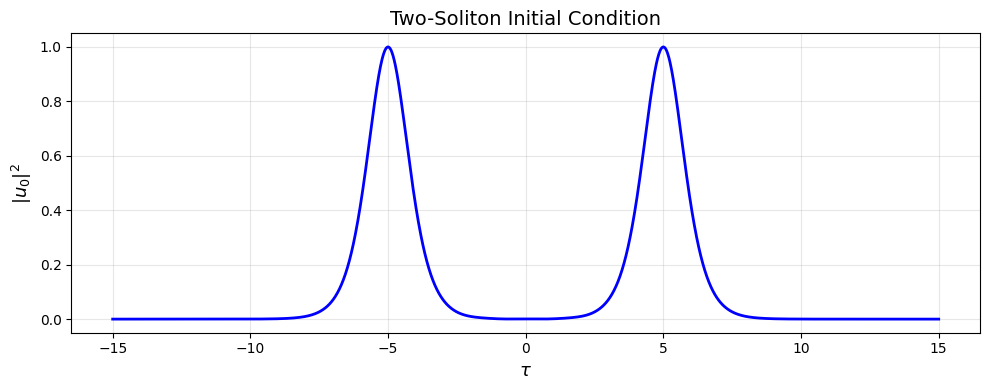

In [2]:
N_t = 4096
tau_window = 30.0
tau, omega, dtau = create_grid(N_t=N_t, tau_window=tau_window)

tau_1 = -5.0
tau_2 = +5.0
Omega_1 = +2.0
Omega_2 = -2.0

def stable_sech(x):
    """Numerically stable sech(x)."""
    abs_x = np.abs(x)
    return 2 * np.exp(-abs_x) / (1 + np.exp(-2 * abs_x))

u0 = (stable_sech(tau - tau_1) * np.exp(1j * Omega_1 * tau) +
      stable_sech(tau - tau_2) * np.exp(1j * Omega_2 * tau))

xi_max = 5.0
N_z = 2000
s = 1
N_sq = 1.0

E0 = compute_energy(u0, dtau)
print(f"Initial energy: {E0:.4f}")
print(f"Expected (2 solitons x 2.0 each): ~4.0")
print(f"  (Slightly different due to overlap between solitons)")

fig, ax = plt.subplots(figsize=(10, 4))
mask_init = (tau >= -15) & (tau <= 15)
ax.plot(tau[mask_init], np.abs(u0[mask_init])**2, 'b-', linewidth=2)
ax.set_xlabel(r'$\tau$', fontsize=13)
ax.set_ylabel(r'$|u_0|^2$', fontsize=13)
ax.set_title('Two-Soliton Initial Condition', fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [3]:
xi_arr, u_hist = ssfm_propagate(u0, tau, omega, xi_max=xi_max, N_z=N_z, s=s, N_sq=N_sq)
print(f"Propagation complete: {u_hist.shape}")

Propagation complete: (2001, 4096)
